Accuracy: 0.9796511627906976

Classification Report
              precision    recall  f1-score   support

           1       0.98      0.98      0.98       907
           2       0.98      0.97      0.98       813

    accuracy                           0.98      1720
   macro avg       0.98      0.98      0.98      1720
weighted avg       0.98      0.98      0.98      1720

Confusion Matrix
[[893  14]
 [ 21 792]]

Predicted Digit: 1


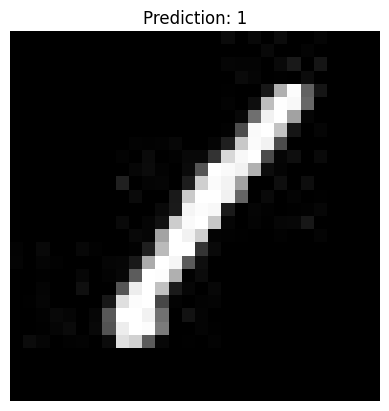

In [108]:
import os
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# -------------------------
# Function to load one digit
# -------------------------
def load_digit_images(folder_path, label):
    data = []

    for filename in os.listdir(folder_path):
        filepath = os.path.join(folder_path, filename)

        img = plt.imread(filepath)
        data.append(img.flatten())

    df = pd.DataFrame(data)
    df["label"] = label

    return df


# -------------------------
# Load training data
# -------------------------
digit1 = load_digit_images("./../MNIST/train/1", 1)
digit2 = load_digit_images("./../MNIST/train/2", 2)

dataset = pd.concat([digit1, digit2], ignore_index=True)

# Shuffle the dataset
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)


# -------------------------
# Features and labels
# -------------------------
X = dataset.drop(columns="label")
y = dataset["label"]


# -------------------------
# Train/Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# -------------------------
# Train Decision Tree
# -------------------------
clf = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

clf.fit(X_train, y_train)


# -------------------------
# Evaluate Model
# -------------------------
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print("Classification Report")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))


# -------------------------
# Predict a New Image
# -------------------------
test_img = plt.imread("./../MNIST/test/1/img_0.jpg")
test_sample = test_img.flatten()

prediction = clf.predict([test_sample])[0]

print(f"\nPredicted Digit: {prediction}")


# -------------------------
# Display Image
# -------------------------
plt.imshow(test_img, cmap="gray")
plt.title(f"Prediction: {prediction}")
plt.axis("off")
plt.show()